In [1]:
import transformers
import torch
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core import Settings, SimpleDirectoryReader, VectorStoreIndex
from llama_index.core.retrievers import VectorIndexRetriever
from llama_index.core.query_engine import RetrieverQueryEngine
from llama_index.core.postprocessor import SimilarityPostprocessor
from peft import PeftModel, PeftConfig


class LLMHandler:
    def __init__(
        self,
        model_id: str,
        token: str,
        max_new_tokens: int = 4096,
        temperature: float = 0.1,
        device_map: str = "auto",
        torch_dtype=torch.bfloat16,
        use_peft: bool = False,
    ):
        """
        Initialize the LLMHandler with a HuggingFace pipeline for text generation,
        or manually for PEFT-adapted models.
        """
        self.model_id = model_id
        self.max_new_tokens = max_new_tokens
        self.temperature = temperature
        self.use_peft = use_peft

        if use_peft:
            print(f"[Info] Detected PEFT adapter at {model_id}")
            self.tokenizer = transformers.AutoTokenizer.from_pretrained(model_id, token=token)
            base_model_path = PeftConfig.from_pretrained(model_id, token=token).base_model_name_or_path
            base_model = transformers.AutoModelForCausalLM.from_pretrained(
                base_model_path,
                device_map=device_map,
                torch_dtype=torch_dtype,
                token=token
            )
            self.model = PeftModel.from_pretrained(base_model, model_id, token=token)
            self.model.eval()
        else:
            self.generator_pipeline = transformers.pipeline(
                "text-generation",
                model=model_id,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                model_kwargs={"torch_dtype": torch_dtype},
                device_map=device_map,
                token=token,
                truncation=True
            )

        print(f"[Initialized] LLM pipeline using model: {model_id}")

    def generate(self, prompt: str, max_new_tokens: int = None, system_prompt: str = None) -> str:
        """
        Query the LLM with a given prompt and return the response.
        Optionally include a system prompt.
        """
        if max_new_tokens is None:
            max_new_tokens = self.max_new_tokens

        messages = []
        if system_prompt:
            messages.append({"role": "system", "content": system_prompt})
        messages.append({"role": "user", "content": prompt})

        if self.use_peft:
            input_text = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = self.tokenizer(input_text, return_tensors="pt").to(self.model.device)
            with torch.no_grad():
                outputs = self.model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=self.temperature,
                    pad_token_id=self.tokenizer.eos_token_id
                )
            return self.tokenizer.decode(outputs[0], skip_special_tokens=True)

        else:
            outputs = self.generator_pipeline(
                messages,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.generator_pipeline.tokenizer.eos_token_id
            )
            return outputs[0]["generated_text"][-1]["content"]

    def initialize_rag(self, documents_path: str, embed_model_name: str, top_k: int = 5, similarity_cutoff: float = 0.6, chunk_size: int = 512, overlap: int = 20):
        """
        Initialize the RAG components, including embeddings, retrievers, and query engine.
        """
        self.top_k = top_k
        self.similarity_cutoff = similarity_cutoff

        Settings.llm = None
        Settings.chunk_size = chunk_size
        Settings.overlap = overlap
        Settings.embed_model = HuggingFaceEmbedding(model_name=embed_model_name)

        documents = SimpleDirectoryReader(documents_path, recursive=True).load_data()
        self.index = VectorStoreIndex.from_documents(documents)

        self.retriever = VectorIndexRetriever(
            index=self.index,
            similarity_top_k=top_k
        )
        self.rag_query_engine = RetrieverQueryEngine(
            retriever=self.retriever,
            node_postprocessors=[SimilarityPostprocessor(similarity_cutoff=similarity_cutoff)]
        )
        print(f"Initialized RAG with {len(documents)} documents and embedding model: {embed_model_name}")

    def get_context_using_rag(self, query_prompt: str) -> str:
        """
        Retrieve relevant context using RAG and combine it with the query prompt for a more informed response.
        """
        if self.rag_query_engine is None:
            raise ValueError("RAG is not initialized. Please call `initialize_rag` before using this method.")

        retrieved_examples = self.rag_query_engine.query(query_prompt)
        context = ""
        for i in range(min(self.top_k, len(retrieved_examples.source_nodes))):
            context += retrieved_examples.source_nodes[i].text + "\n\n"

        return context

/home/mridum/miniconda3/envs/ontology/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

hf_token = os.getenv("HF_TOKEN")

llm = LLMHandler(
    model_id="Qwen/Qwen3-30B-A3B-Instruct-2507",
    token=hf_token
)

Loading checkpoint shards: 100%|██████████| 16/16 [00:23<00:00,  1.44s/it]
Device set to use cuda:0


[Initialized] LLM pipeline using model: Qwen/Qwen3-30B-A3B-Instruct-2507


In [ ]:
prompt = """

You are given:

1. 10 life insurance contracts (labeled C1–C10).
2. A file containing 58 scenarios/queries. Each scenario has a unique "scenario_id".

Your task is to carefully review each contract and determine how it applies to each scenario.


INSTRUCTIONS

For EVERY scenario, analyze ALL 10 contracts and determine whether the scenario is:

COVERED
The contract covers the scenario.

DENIED
The contract denies the scenario.

NOT_APPLICABLE
The scenario is out of the scope of the contract. The contract does not mention or address the scenario in any way.

You must support every classification with a relevant clause, sentence, or excerpt from the contract.



OUTPUT REQUIREMENTS

Your response MUST be strictly formatted as JSON using the structure below.

Requirements:
- Include every scenario from the scenario file.
- For each scenario, include responses for all 10 contracts (C1–C10).
- Use the exact "scenario_id" from the scenario file.
- "status" must be exactly one of: COVERED, DENIED, NOT_APPLICABLE.


REQUIRED JSON FORMAT

[
  {
    "scenario_id": "<exact scenario_id from the scenario file>",
    "contract_responses": [
      {
        "contract_id": "C1 | C2 | ... | C10",
        "status": "COVERED | DENIED | NOT_APPLICABLE",
        "source": "<relevant clause or excerpt from the contract supporting the status>"
      }
    ]
  }
]

"""

In [3]:
import json
import os
from pathlib import Path
from collections import Counter

In [4]:
def load_ground_truth(folder_path):
    """
    Creates a mapping of:
    scenario_id -> {
        "description": scenario_description,
        "contracts": { contract_id: {status, source} }
    }
    """
    truth_map = {}
    path = Path(folder_path)
    for json_file in path.glob("*.json"):
        with open(json_file, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                scenarios = data if isinstance(data, list) else [data]
                for sc in scenarios:
                    s_id = sc.get('scenario_id')
                    if not s_id: continue
                    
                    truth_map[s_id] = {
                        "description": sc.get('scenario_description', ''),
                        "contracts": {
                            res['contract_id']: {
                                "status": res['status'],
                                "source": res.get('source', res.get('details', '')) 
                            }
                            for res in sc.get('contract_responses', [])
                        }
                    }
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON file: {json_file}")
    return truth_map

def generate_comparison_json(truth_folder, llm_folder, output_filename="evaluation_results.json"):
    truth_map = load_ground_truth(truth_folder)
    llm_path = Path(llm_folder)
    
    final_report = {}

    for llm_file in llm_path.glob("*.json"):
        file_name = llm_file.name
        with open(llm_file, 'r', encoding='utf-8') as f:
            try:
                llm_scenarios = json.load(f)
            except json.JSONDecodeError:
                continue
        
        file_data = {}
        
        for sc in llm_scenarios:
            s_id = sc.get('scenario_id')
            if s_id not in truth_map:
                continue

            matches = []
            mismatches = []
            
            for res in sc.get('contract_responses', []):
                c_id = res['contract_id']
                llm_status = res['status']
                llm_source = res.get('source', '')
                
                if c_id in truth_map[s_id]["contracts"]:
                    truth = truth_map[s_id]["contracts"][c_id]
                    
                    if llm_status == truth['status']:
                        matches.append(c_id)
                    else:
                        mismatches.append({
                            "contract_id": c_id,
                            "llm_status": llm_status,
                            "ground_truth_status": truth['status'],
                            "llm_source": llm_source,
                            "ground_truth_source": truth['source']
                        })
            
            file_data[s_id] = {
                "scenario_description": truth_map[s_id]["description"],
                "matched_contracts": matches,
                "mismatched_contracts": mismatches
            }
        
        final_report[file_name] = file_data

    with open(output_filename, 'w', encoding='utf-8') as out_f:
        json.dump(final_report, out_f, indent=4)
    
    print(f"Success! Comparison report saved to {output_filename}")


truth_dir = "../../dataset/scenarios"
llm_dir = "llm_responses"

generate_comparison_json(truth_dir, llm_dir)

Success! Comparison report saved to evaluation_results.json


In [5]:
def analyze_evaluation_json_by_file(json_input):
    """
    Reads the evaluation JSON and generates the requested multi-view 
    analytics for each file individually.
    """
    if isinstance(json_input, str):
        with open(json_input, 'r', encoding='utf-8') as f:
            data = json.load(f)
    else:
        data = json_input

    for file_name, scenarios in data.items():
        
        scenario_hardness = {}
        contract_reliability = {}
        category_mismatches = []
        total_correct = 0
        total_contracts = 0

        for s_id, content in scenarios.items():
            matches = content.get("matched_contracts", [])
            mismatches = content.get("mismatched_contracts", [])
            
            m_count = len(matches)
            mm_count = len(mismatches)
            total_scen = m_count + mm_count
            
            total_correct += m_count
            total_contracts += total_scen

            if s_id not in scenario_hardness:
                scenario_hardness[s_id] = {"correct": 0, "total": 0, "desc": content.get("scenario_description", "")}
            scenario_hardness[s_id]["correct"] += m_count
            scenario_hardness[s_id]["total"] += total_scen

            for m in mismatches:
                c_id = m["contract_id"]
                if c_id not in contract_reliability:
                    contract_reliability[c_id] = {"correct": 0, "total": 0}
                contract_reliability[c_id]["total"] += 1
                
                category_mismatches.append(f"{m['ground_truth_status']} -> {m['llm_status']}")

            for c_id in matches:
                if c_id not in contract_reliability:
                    contract_reliability[c_id] = {"correct": 0, "total": 0}
                contract_reliability[c_id]["correct"] += 1
                contract_reliability[c_id]["total"] += 1

        
        print(f"\n{'='*80}")
        print(f"REPORT FOR: {file_name}")
        print(f"{'='*80}")

        # View 1: Overall Accuracy for this file
        acc = (total_correct / total_contracts * 100) if total_contracts > 0 else 0
        print(f"\n[View 1: File Performance]")
        print(f"  Accuracy: {acc:>6.2f}% ({total_correct}/{total_contracts})")

        # View 2: Hardest Scenarios (Lowest Success Rate) for this file
        print("\n[View 2: Hardest Scenarios (Lowest Success Rate)]")
        scen_list = []
        for s_id, stats in scenario_hardness.items():
            rate = (stats["correct"] / stats["total"] * 100) if stats["total"] > 0 else 0
            scen_list.append((s_id, rate, stats["desc"]))
        
        for s_id, rate, desc in sorted(scen_list, key=lambda x: x[1])[:5]:
            print(f"  - {s_id:<10} | Success: {rate:>6.2f}% | {desc[:60]}...")

        # View 3: Most Error-Prone Contracts for this file
        print("\n[View 3: Most Error-Prone Contracts]")
        cont_list = []
        for c_id, stats in contract_reliability.items():
            rate = (stats["correct"] / stats["total"] * 100) if stats["total"] > 0 else 0
            cont_list.append((c_id, rate))
        
        for c_id, rate in sorted(cont_list, key=lambda x: x[1])[:5]:
            print(f"  - Contract {c_id:<5} | Accuracy: {rate:>6.2f}%")

        # View 4: Logic Error Trends for this file
        print("\n[View 4: Common Logic Mismatches (Truth -> LLM)]")
        trends = Counter(category_mismatches).most_common(3)
        if trends:
            for trend, count in trends:
                print(f"  - {trend:<25} | Occurred {count} times")
        else:
            print("  - No logic mismatches found!")

analyze_evaluation_json_by_file("evaluation_results.json")


REPORT FOR: chatgpt_5.3.json

[View 1: File Performance]
  Accuracy:  72.93% (423/580)

[View 2: Hardest Scenarios (Lowest Success Rate)]
  - SCEN-053   | Success:   0.00% | On a joint survivorship policy, the first insured dies with ...
  - SCEN-028   | Success:  10.00% | Both joint insureds die in the same car accident and are pro...
  - SCEN-047   | Success:  10.00% | A whole life policy owner stops paying premiums. After the g...
  - SCEN-049   | Success:  10.00% | The primary beneficiary of a life insurance policy wishes to...
  - SCEN-052   | Success:  10.00% | On a joint survivorship policy, the annual premium due on Au...

[View 3: Most Error-Prone Contracts]
  - Contract C8    | Accuracy:  65.52%
  - Contract C4    | Accuracy:  68.97%
  - Contract C10   | Accuracy:  68.97%
  - Contract C7    | Accuracy:  70.69%
  - Contract C9    | Accuracy:  70.69%

[View 4: Common Logic Mismatches (Truth -> LLM)]
  - NOT_APPLICABLE -> COVERED | Occurred 90 times
  - NOT_APPLICABLE -> DENIED

In [6]:
import json
from collections import Counter

def analyze_evaluation_json(json_input):
    if isinstance(json_input, str):
        with open(json_input, 'r', encoding='utf-8') as f:
            data = json.load(f)
    else:
        data = json_input

    global_stats = {
        "total_correct": 0,
        "total_contracts": 0,
        "scenario_hardness": {},
        "contract_reliability": {},
        "category_mismatches": []
    }

    for file_name, scenarios in data.items():
        f_correct = 0
        f_total = 0
        f_mismatches = []

        for s_id, content in scenarios.items():
            matches = content.get("matched_contracts", [])
            mismatches = content.get("mismatched_contracts", [])
            
            m_count = len(matches)
            mm_count = len(mismatches)
            t_scen = m_count + mm_count
            
            f_correct += m_count
            f_total += t_scen
            global_stats["total_correct"] += m_count
            global_stats["total_contracts"] += t_scen

            if s_id not in global_stats["scenario_hardness"]:
                global_stats["scenario_hardness"][s_id] = {"correct": 0, "total": 0, "desc": content.get("scenario_description", "")}
            global_stats["scenario_hardness"][s_id]["correct"] += m_count
            global_stats["scenario_hardness"][s_id]["total"] += t_scen

            for m in mismatches:
                c_id = m["contract_id"]
                label = f"{m['ground_truth_status']} -> {m['llm_status']}"
                f_mismatches.append(label)
                global_stats["category_mismatches"].append(label)
                
                if c_id not in global_stats["contract_reliability"]:
                    global_stats["contract_reliability"][c_id] = {"correct": 0, "total": 0}
                global_stats["contract_reliability"][c_id]["total"] += 1

            for c_id in matches:
                if c_id not in global_stats["contract_reliability"]:
                    global_stats["contract_reliability"][c_id] = {"correct": 0, "total": 0}
                global_stats["contract_reliability"][c_id]["correct"] += 1
                global_stats["contract_reliability"][c_id]["total"] += 1

        print_report(f"FILE: {file_name}", f_correct, f_total, f_mismatches)

    print("\n" + "="*80)
    print(f"{'OVERALL AGGREGATE ANALYSIS':^80}")
    print("="*80)
    
    g_acc = (global_stats["total_correct"] / global_stats["total_contracts"] * 100) if global_stats["total_contracts"] > 0 else 0
    print(f"\n[Global Performance]")
    print(f"  Total Accuracy: {g_acc:>6.2f}% ({global_stats['total_correct']}/{global_stats['total_contracts']})")

    print("\n[Global: Top 5 Hardest Scenarios]")
    g_scen_list = []
    for s_id, stats in global_stats["scenario_hardness"].items():
        rate = (stats["correct"] / stats["total"] * 100) if stats["total"] > 0 else 0
        g_scen_list.append((s_id, rate, stats["desc"]))
    
    for s_id, rate, desc in sorted(g_scen_list, key=lambda x: x[1])[:5]:
        print(f"  - {s_id:<10} | Success: {rate:>6.2f}% | {desc[:60]}...")

    print("\n[Global: Top 5 Most Error-Prone Contracts]")
    g_cont_list = []
    for c_id, stats in global_stats["contract_reliability"].items():
        rate = (stats["correct"] / stats["total"] * 100) if stats["total"] > 0 else 0
        g_cont_list.append((c_id, rate))
    
    for c_id, rate in sorted(g_cont_list, key=lambda x: x[1])[:5]:
        print(f"  - Contract {c_id:<5} | Accuracy: {rate:>6.2f}%")

    print("\n[Global: Most Frequent Logic Mismatches]")
    g_trends = Counter(global_stats["category_mismatches"]).most_common(5)
    for trend, count in g_trends:
        print(f"  - {trend:<25} | Total Occurrences: {count}")

def print_report(title, correct, total, mismatches):
    acc = (correct / total * 100) if total > 0 else 0
    print(f"\n{title}")
    print(f"  Accuracy: {acc:.2f}% | Mismatches: {len(mismatches)}")

analyze_evaluation_json("evaluation_results.json")


FILE: chatgpt_5.3.json
  Accuracy: 72.93% | Mismatches: 157

FILE: gemini_3.json
  Accuracy: 65.17% | Mismatches: 202

FILE: claude_sonnet_4.6.json
  Accuracy: 87.76% | Mismatches: 71

                           OVERALL AGGREGATE ANALYSIS                           

[Global Performance]
  Total Accuracy:  75.29% (1310/1740)

[Global: Top 5 Hardest Scenarios]
  - SCEN-035   | Success:  20.00% | The insured dies in a car accident that is the direct cause ...
  - SCEN-008   | Success:  26.67% | After several years, the policy owner stops paying premiums ...
  - SCEN-046   | Success:  26.67% | The insured dies in a car accident. Toxicology confirms the ...
  - SCEN-053   | Success:  36.67% | On a joint survivorship policy, the first insured dies with ...
  - SCEN-024   | Success:  40.00% | An applicant with severe pre-existing health conditions (can...

[Global: Top 5 Most Error-Prone Contracts]
  - Contract C8    | Accuracy:  70.11%
  - Contract C9    | Accuracy:  70.69%
  - Contract C6 

In [7]:
from collections import defaultdict

def print_mismatches_by_scenario(json_input):
    """
    Pivots the evaluation data to group results by Scenario ID rather than by File.
    Prints every contract failure across all tested LLMs for that specific scenario.
    """
    if isinstance(json_input, str):
        with open(json_input, 'r', encoding='utf-8') as f:
            data = json.load(f)
    else:
        data = json_input

    scenario_pivot = defaultdict(list)
    scenario_descriptions = {}

    for file_name, scenarios in data.items():
        for s_id, content in scenarios.items():
            scenario_descriptions[s_id] = content.get("scenario_description", "N/A")
            mismatches = content.get("mismatched_contracts", [])
            
            for m in mismatches:
                m_entry = m.copy()
                m_entry['llm_file'] = file_name
                scenario_pivot[s_id].append(m_entry)

    print(f"\n{'#'*100}")
    print(f"{'SCENARIO-BY-SCENARIO FAILURE ANALYSIS':^100}")
    print(f"{'#'*100}\n")

    if not scenario_pivot:
        print("No mismatches found across any scenarios.")
        return

    for s_id in sorted(scenario_pivot.keys()):
        mismatches = scenario_pivot[s_id]
        desc = scenario_descriptions[s_id]

        print(f"### SCENARIO: {s_id}")
        print(f"### DESCRIPTION: {desc}")
        print("-" * 100)
        
        for m in mismatches:
            print(f"  [LLM SOURCE FILE] : {m['llm_file']}")
            print(f"  [CONTRACT ID]     : {m['contract_id']}")
            print(f"  [EXPECTED]        : {m['ground_truth_status']}")
            print(f"  [EXPECTED WHY]    : {m['ground_truth_source']}")
            print(f"  [LLM ACTUAL]      : {m['llm_status']}")
            print(f"  [LLM WHY]         : {m['llm_source']}")
            print(f"  {'.' * 60}")
        
        print(f"\n{'='*100}\n")

print_mismatches_by_scenario("evaluation_results.json")


####################################################################################################
                               SCENARIO-BY-SCENARIO FAILURE ANALYSIS                                
####################################################################################################

### SCENARIO: SCEN-001
### DESCRIPTION: Insured dies from natural causes (heart attack) 5 years after policy issue. All premiums paid on time. No outstanding loans.
----------------------------------------------------------------------------------------------------
  [LLM SOURCE FILE] : chatgpt_5.3.json
  [CONTRACT ID]     : C8
  [EXPECTED]        : DENIED
  [EXPECTED WHY]    : Article I, 1.2: 'DEATH BENEFIT TRIGGER: The death benefit is payable only upon the death of the SECOND insured to die (survivorship basis). If the first insured dies, no death benefit is paid and the policy continues in force covering the surviving insured.'
  [LLM ACTUAL]      : NOT_APPLICABLE
  [LLM WHY]       

In [8]:
import json
from collections import Counter, defaultdict
from pathlib import Path

def analyze_full_suite(json_file_path):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    llm_names = list(data.keys())
    global_stats = {
        "total_correct": 0,
        "total_contracts": 0,
        "scenario_hardness": {},
        "contract_reliability": {},
        "category_mismatches": []
    }
    
    consensus_tracker = defaultdict(dict)
    ground_truth_map = {}

    for llm_name, scenarios in data.items():
        f_correct = 0
        f_total = 0
        
        for s_id, content in scenarios.items():
            matches = content.get("matched_contracts", [])
            mismatches = content.get("mismatched_contracts", [])
            
            f_correct += len(matches)
            f_total += (len(matches) + len(mismatches))
            
            if s_id not in global_stats["scenario_hardness"]:
                global_stats["scenario_hardness"][s_id] = {"correct": 0, "total": 0, "desc": content.get("scenario_description", "")}
            global_stats["scenario_hardness"][s_id]["correct"] += len(matches)
            global_stats["scenario_hardness"][s_id]["total"] += (len(matches) + len(mismatches))

            for c_id in matches:
                consensus_tracker[(s_id, c_id)][llm_name] = "CORRECT"
                
                if c_id not in global_stats["contract_reliability"]:
                    global_stats["contract_reliability"][c_id] = {"correct": 0, "total": 0}
                global_stats["contract_reliability"][c_id]["correct"] += 1
                global_stats["contract_reliability"][c_id]["total"] += 1

            for m in mismatches:
                c_id = m["contract_id"]
                label = f"{m['ground_truth_status']} -> {m['llm_status']}"
                global_stats["category_mismatches"].append(label)
                consensus_tracker[(s_id, c_id)][llm_name] = m['llm_status']
                ground_truth_map[(s_id, c_id)] = m['ground_truth_status']
                
                if c_id not in global_stats["contract_reliability"]:
                    global_stats["contract_reliability"][c_id] = {"correct": 0, "total": 0}
                global_stats["contract_reliability"][c_id]["total"] += 1

        print(f"Processed {llm_name}: Accuracy {(f_correct/f_total*100):.2f}%")

    agreement_types = Counter()
    for (s_id, c_id), preds in consensus_tracker.items():
        correct_count = list(preds.values()).count("CORRECT")
        unique_wrong_preds = set(v for v in preds.values() if v != "CORRECT")
        
        if correct_count == len(llm_names):
            agreement_types["Unanimous Correct"] += 1
        elif correct_count > (len(llm_names) / 2):
            agreement_types["Majority Correct"] += 1
        elif correct_count == 0 and len(unique_wrong_preds) == 1:
            agreement_types["Unanimous Incorrect (Shared Error)"] += 1
        elif correct_count > 0:
            agreement_types["Contested (Mixed Success)"] += 1
        else:
            agreement_types["Complete Chaos (All Wrong & Different)"] += 1

    print("\n" + "="*60)
    print(f"{'FINAL RESEARCH METRICS':^60}")
    print("="*60)

    print(f"\n[Table 1: Inter-LLM Agreement (n={len(consensus_tracker)} pairs)]")
    for category, count in agreement_types.items():
        perc = (count / len(consensus_tracker)) * 100
        print(f"  - {category:<35}: {count:>4} ({perc:>5.1f}%)")

    print("\n[Table 2: Top Logic Errors (Truth -> LLM Prediction)]")
    trends = Counter(global_stats["category_mismatches"]).most_common(5)
    for trend, count in trends:
        print(f"  - {trend:<35}: {count:>4} occurrences")

    print("\n[Table 3: High-Difficulty Scenarios (Global)]")
    scen_list = [(s_id, (stats["correct"]/stats["total"]*100), stats["desc"]) 
                 for s_id, stats in global_stats["scenario_hardness"].items()]
    for s_id, rate, desc in sorted(scen_list, key=lambda x: x[1])[:3]:
        print(f"  - {s_id} ({rate:>5.1f}% Accuracy): {desc[:70]}...")

try:
    analyze_full_suite("evaluation_results.json")
except FileNotFoundError:
    print("Error: 'evaluation_results.json' not found. Please run your comparison script first.")

Processed chatgpt_5.3.json: Accuracy 72.93%
Processed gemini_3.json: Accuracy 65.17%
Processed claude_sonnet_4.6.json: Accuracy 87.76%

                   FINAL RESEARCH METRICS                   

[Table 1: Inter-LLM Agreement (n=580 pairs)]
  - Unanimous Correct                  :  283 ( 48.8%)
  - Unanimous Incorrect (Shared Error) :   33 (  5.7%)
  - Majority Correct                   :  203 ( 35.0%)
  - Complete Chaos (All Wrong & Different):    6 (  1.0%)
  - Contested (Mixed Success)          :   55 (  9.5%)

[Table 2: Top Logic Errors (Truth -> LLM Prediction)]
  - NOT_APPLICABLE -> DENIED           :  207 occurrences
  - NOT_APPLICABLE -> COVERED          :  126 occurrences
  - COVERED -> NOT_APPLICABLE          :   30 occurrences
  - COVERED -> DENIED                  :   30 occurrences
  - DENIED -> COVERED                  :   23 occurrences

[Table 3: High-Difficulty Scenarios (Global)]
  - SCEN-035 ( 20.0% Accuracy): The insured dies in a car accident that is the direct c

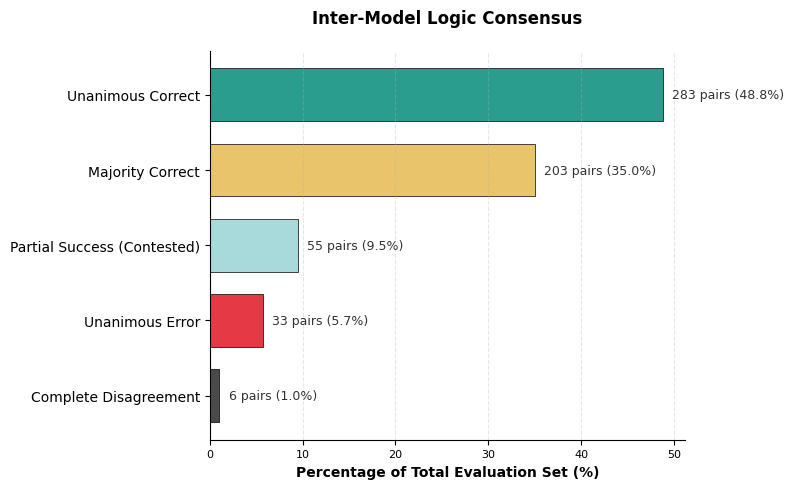

In [10]:
import json
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter, defaultdict

def generate_professional_consensus_chart(json_input):
    with open(json_input, 'r', encoding='utf-8') as f:
        data = json.load(f)

    llm_names = list(data.keys())
    matrix = defaultdict(dict)
    
    for llm_name, scenarios in data.items():
        for s_id, content in scenarios.items():
            for c_id in content.get("matched_contracts", []):
                matrix[(s_id, c_id)][llm_name] = "CORRECT"
            for m in content.get("mismatched_contracts", []):
                c_id = m["contract_id"]
                matrix[(s_id, c_id)][llm_name] = m['llm_status']

    agreement_counts = Counter()
    
    for (s_id, c_id), preds in matrix.items():
        if len(preds) < len(llm_names):
            continue 
            
        statuses = list(preds.values())
        unique_statuses = set(statuses)
        correct_count = statuses.count("CORRECT")
        
        if correct_count == len(llm_names):
            agreement_counts["Unanimous Correct"] += 1
        elif correct_count == 0 and len(unique_statuses) == 1:
            agreement_counts["Unanimous Error"] += 1
        elif correct_count > (len(llm_names) / 2):
            agreement_counts["Majority Correct"] += 1
        elif correct_count > 0:
            agreement_counts["Partial Success (Contested)"] += 1
        else:
            agreement_counts["Complete Disagreement"] += 1

    df = pd.Series(agreement_counts).sort_values(ascending=True)
    labels = df.index
    values = df.values
    percentages = (values / sum(values)) * 100

    colors = ['#4a4a4a', '#e63946', '#a8dadc', '#e9c46a', '#2a9d8f']
    
    plt.style.use('default') 
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.patch.set_facecolor('white')

    bars = ax.barh(labels, percentages, color=colors, height=0.7, edgecolor='black', linewidth=0.5)

    for i, (p, v) in enumerate(zip(percentages, values)):
        ax.text(p + 1, i, f"{int(v)} pairs ({p:.1f}%)", va='center', fontsize=9, color='#333333')

    ax.set_xlabel('Percentage of Total Evaluation Set (%)', fontsize=10, fontweight='bold')
    ax.set_title('Inter-Model Logic Consensus', fontsize=12, fontweight='bold', pad=20)
    
    ax.tick_params(axis='y', which='major', labelsize=10)
    ax.tick_params(axis='x', which='major', labelsize=8)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

generate_professional_consensus_chart("evaluation_results.json")